# NEW THINGS
take out PCA and work directly with the 384 dimensions

# Simplified Implementation of V1 Methodolohy

This notebook serves to quickly showcase an easy implmentation of the methodology used for the AREP on News Embeddings in Energy Prices. No unit test have been written to keep the code a little cleaner

---


### Importing Required Libraries

This section imports all necessary libraries for our analysis:
- **Core libraries**: pandas, numpy, datetime, and json for data manipulation
- **API libraries**: newsapi for fetching news articles from NewsAPI.org
- **NLP libraries**: sentence_transformers for generating embeddings
- **ML libraries**: scikit-learn for PCA and model evaluation, XGBoost for gradient boosting
- **Visualization**: matplotlib for plotting results
- **Utilities**: tqdm for progress bars, dotenv for environment variables

In [2]:
# Core libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import json
from tqdm import tqdm

# API libraries
from newsapi import NewsApiClient

# NLP libraries
from sentence_transformers import SentenceTransformer

# ML Libraries
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Other libraries
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt

/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

# Data Collection

## News Data

To understand how news sentiment impacts energy prices, we need to collect relevant news articles. We'll use NewsAPI.org to fetch headlines from German news sources focusing on energy-related topics.

First, we define a function to fetch news articles. This function handles:
- Date range splitting into weekly increments to comply with API rate limits
- Keyword-based filtering for energy-related terms
- Deduplication and validation of fetched articles
- Returning a clean DataFrame with publication timestamps

In [3]:
def fetch_news_data(start_date: str, end_date: str, language: str, keywords: str, source: str, api_key: str) -> pd.DataFrame:
    """
    Fetch news articles from NewsAPI.org with flexible keywords.
    
    Parameters:
        start_date : Start date in format 'YYYY-MM-DD'
        end_date : End date in format 'YYYY-MM-DD'
        language : Language of the news articles (str)
        keywords : Search keywords (str)
        source : List of sources (str)
        api_key : str
    
    Returns:
        DataFrame with columns: 'publishedAt', 'title', 'source', 'url'
    """
    
    # Initialisation
    newsapi = NewsApiClient(api_key=api_key)
    #SOURCES = 'bild, der-tagesspiegel,die-zeit,focus,handelsblatt,spiegel-online,wirtschafts-woche'
    
    # Calculate date ranges to fetch in weekly increments (data limits)
    end_date = datetime.strptime(end_date, '%Y-%m-%d')
    start_date = datetime.strptime(start_date, '%Y-%m-%d')
    all_articles = []

    total_days = (end_date - start_date).days
    num_periods = (total_days // 7) + (1 if total_days % 7 > 0 else 0)

    # Loop for fetching data
    for period in range(num_periods):
        
        to_date = end_date - timedelta(days=period * 7)
        from_date = to_date - timedelta(days=7)
        from_str = from_date.strftime('%Y-%m-%d')
        to_str = to_date.strftime('%Y-%m-%d')

        articles_period = newsapi.get_everything(
            q=keywords,
            sources=source,
            language=language,
            sort_by='relevancy',
            from_param=from_str,
            to=to_str,
            page_size=100
        )
        
        all_articles.extend(articles_period['articles'])

    # Conversion to DataFrame
    news_df = pd.DataFrame([
        {
            'publishedAt': article['publishedAt'],
            'title': article.get('title', ''),
            'source': article['source']['name'],
        }
        for article in all_articles
    ])

    # Date Conversion, Sorting and Duplicate Removal + Validation Check
    news_df['publishedAt'] = pd.to_datetime(news_df['publishedAt'])
    news_df = news_df.sort_values('publishedAt')
    news_df = news_df.drop_duplicates(subset=['title'], keep='first')

    if news_df.empty:
        print("Warning: No articles fetched!")
        return pd.DataFrame(columns=['publishedAt', 'title', 'source'])
    else:
        print(f"Successfully fetched {len(news_df)} articles")
        return news_df

Now that we have our data fetching function, we'll configure the search parameters:
- **Date range**: January 1, 2025 to October 1, 2025
- **Language**: German (de)
- **Keywords**: Energy-related terms in German including "Energie", "Strom", "Energiewende", "Kraftwerk", "Erneuerbare" (renewables), "Stromversorgung" (power supply), "Stromerzeugung" (power generation), etc.
- **Sources**: Major German news outlets including Bild, Die Zeit, Handelsblatt, Spiegel Online, WirtschaftsWoche, etc.

We then fetch the news data using these parameters.

In [4]:
# Define our search parameters
start_date = '2025-01-01'
end_date = '2025-10-01'
language = 'de'
keywords = (
    '"Energie" OR "Strom" OR "Energiewende" OR "Kraftwerk" OR '
    '"Erneuerbare" OR "Stromversorgung" OR "Energieversorgung" OR '
    '"Stromerzeugung" OR "Energieerzeugung"'
)
source = 'bild, der-tagesspiegel,die-zeit,focus,handelsblatt,spiegel-online,wirtschafts-woche'

load_dotenv()
NEWS_API_KEY = os.getenv('NEWSAPIORG_KEY')


# Fetch the data
news_df = fetch_news_data(start_date, end_date, language, keywords, source, NEWS_API_KEY)

Successfully fetched 3180 articles


## Energy Price Data

We obtain historical energy market data from energy-charts.info, which provides hourly German electricity market data. In this notebook, the data is stored as a JSON file for 2025.

We extract the following key variables:
- **Spot prices**: Real-time electricity prices (€/MWh)
- **Auction prices**: Day-ahead auction prices (€/MWh)
- **Load**: Total electricity demand (MW)
- **Renewables**: Power generation from renewable sources (MW)
- **Non-renewables**: Power generation from conventional sources (MW)

These variables form the foundation of our prediction model.

In [5]:
json_data = json.load(open('data.json', 'r'))

# Set which series we want to use
timestamps = json_data[0]['xAxisValues']
spot_prices = json_data[7]['data']
auction_prices = json_data[6]['data']
load = json_data[4]['data']
renewables = json_data[3]['data']
non_renewables = json_data[2]['data']

# Create a DataFrame for the energy data
energy_df = pd.DataFrame({
    'timestamp': pd.to_datetime(timestamps, unit='ms'),
    'spot_price': spot_prices,
    'auction_price': auction_prices,
    'load': load,
    'renewables': renewables,
    'non_renewables': non_renewables
})

# Set timestamp as index and drop NaN values
energy_df.set_index('timestamp', inplace=True)
energy_df.dropna(inplace=True)

print(energy_df.shape)
energy_df.tail(10)

(6551, 5)


,spot_price,auction_price,load,renewables,non_renewables
timestamp,,,,,
2025-09-30 12:00:00,78.57,87.26,61095.0025,34128.737949,20675.071763
2025-09-30 13:00:00,85.36,96.80,59257.2725,29622.626666,23221.946823
2025-09-30 14:00:00,98.14,104.03,58363.6550,24408.871482,25879.935219
2025-09-30 15:00:00,126.49,142.64,58642.7375,18431.832482,28602.817407
2025-09-30 16:00:00,188.56,294.54,59286.5450,14469.536840,30420.666682
2025-09-30 17:00:00,197.43,357.77,60187.7125,15242.583999,30254.492361
2025-09-30 18:00:00,126.56,147.28,58162.6325,17222.900605,29186.249995
2025-09-30 19:00:00,109.48,116.04,55026.5050,18447.223952,28572.997779
2025-09-30 20:00:00,97.01,101.63,51417.4850,18747.716239,27682.001317


---

# Feature Engineering

This section creates temporal and news-based features for our predictive model. We start by adding simple temporal features derived from the timestamp:
- **Hour**: Hour of the day (0-23)
- **Day of week**: Day of the week (0=Monday, 6=Sunday)
- **Day of year**: Sequential day number (1-365/366)
- **Month**: Month of the year (1-12)
- **Week of year**: ISO week number (1-52/53)

These cyclical features help the model capture intraday, weekly, and seasonal patterns in energy demand and supply.

In [6]:
master_df = energy_df.copy()

# Temporal Features
master_df['hour'] = master_df.index.hour
master_df['day_of_week'] = master_df.index.dayofweek
master_df['day_of_year'] = master_df.index.dayofyear
master_df['month'] = master_df.index.month
master_df['week_of_year'] = master_df.index.isocalendar().week.values

master_df.tail(10)

,spot_price,auction_price,load,renewables,non_renewables,hour,day_of_week,day_of_year,month,week_of_year
timestamp,,,,,,,,,,
2025-09-30 12:00:00,78.57,87.26,61095.0025,34128.737949,20675.071763,12,1,273,9,40
2025-09-30 13:00:00,85.36,96.80,59257.2725,29622.626666,23221.946823,13,1,273,9,40
2025-09-30 14:00:00,98.14,104.03,58363.6550,24408.871482,25879.935219,14,1,273,9,40
2025-09-30 15:00:00,126.49,142.64,58642.7375,18431.832482,28602.817407,15,1,273,9,40
2025-09-30 16:00:00,188.56,294.54,59286.5450,14469.536840,30420.666682,16,1,273,9,40
2025-09-30 17:00:00,197.43,357.77,60187.7125,15242.583999,30254.492361,17,1,273,9,40
2025-09-30 18:00:00,126.56,147.28,58162.6325,17222.900605,29186.249995,18,1,273,9,40
2025-09-30 19:00:00,109.48,116.04,55026.5050,18447.223952,28572.997779,19,1,273,9,40
2025-09-30 20:00:00,97.01,101.63,51417.4850,18747.716239,27682.001317,20,1,273,9,40


## Time-Decayed News Embeddings

To incorporate news sentiment into our predictions, we use a sophisticated approach:
1. **Embedding**: Convert each news article title into a 384-dimensional vector using a multilingual sentence transformer
2. **Time-weighted aggregation**: For each hourly timestamp, compute a weighted average of news articles from the past 168 hours (1 week)
3. **Exponential decay**: Apply exponential time decay where more recent news has higher weight: `weight = exp(-λ × hours_since_publication)`
4. **Dimensionality reduction**: Apply PCA to reduce from 384 dimensions to 20 features
5. **Integration**: Merge the reduced news embeddings into our main DataFrame

This approach ensures that recent, relevant news has more influence on our predictions while older news is gradually forgotten.

First, we'll define a function to compute the time-decayed embeddings:

In [7]:
def compute_time_decayed_embedding(target_time, news_df, decay_lambda=0.1, lookback_hours=168):
    """
    Compute time-weighted average of news embeddings for a specific quarter_hour.
    
    Parameters:
        target_time (datetime): The timestamp we're predicting for
        news_df (DataFrame): News articles with 'publishedAt' and 'embedding' columns
        decay_lambda (float): Decay rate
        lookback_quarter_hours (int): Maximum quarter_hours to look back for news
    
    Returns:
        np.array: Time-weighted average embedding
    """

    news_times = news_df['publishedAt'].dt.tz_localize(None)
    target_time = target_time.tz_localize(None)



    time_window_start = target_time - pd.Timedelta(hours=lookback_hours)

    relevant_news = news_df[
        (news_times < target_time) & 
        (news_times >= time_window_start)
    ]
    
    if len(relevant_news) == 0:
        return np.zeros(384)
    
    hours_ago = (target_time - relevant_news['publishedAt'].dt.tz_localize(None)).values / pd.Timedelta(hours=1)
    weights = np.exp(-decay_lambda * hours_ago)
    weights = weights / weights.sum()
    
    embeddings_array = np.stack(relevant_news['embedding'].values)
    weighted_embedding = (embeddings_array.T @ weights).T
    
    return weighted_embedding


Now we'll execute the embedding pipeline:

1. **Generate embeddings**: Use the multilingual model to encode all news article titles into 384-dimensional vectors
2. **Apply time decay**: For each hourly timestamp in our energy data, compute a weighted average of relevant news from the past 168 hours
3. **Reduce dimensionality**: Apply PCA to extract the 20 most informative components from the embeddings
4. **Combine data**: Add the news embedding features to our main DataFrame as `news_embed_0` through `news_embed_19`

This creates our feature-rich dataset with both temporal and news-based predictors.

In [8]:
# Embed each article
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

article_embeddings = model.encode(
    news_df['title'].tolist(), 
    show_progress_bar=True, 
    batch_size=32
)

news_df['embedding'] = list(article_embeddings)

# Compute time-decayed embedding for each hour in master_df
time_decayed_embeddings = []

for timestamp in tqdm(master_df.index, desc="Processing hours"):
    
    embedding = compute_time_decayed_embedding(
        timestamp, 
        news_df,
        decay_lambda=0.1,
        lookback_hours=168
    )
    time_decayed_embeddings.append(embedding)

time_decayed_embeddings = np.array(time_decayed_embeddings)

# Keep the original embedding dimensions (no PCA)
embedding_dim = time_decayed_embeddings.shape[1]
embedding_columns = [f'news_embed_{i}' for i in range(embedding_dim)]

news_embeddings_df = pd.DataFrame(
    time_decayed_embeddings,
    index=master_df.index,
    columns=embedding_columns
)

master_df = pd.concat([master_df, news_embeddings_df], axis=1)

master_df.tail(10)

Processing hours: 100%|██████████| 6551/6551 [00:02<00:00, 2571.22it/s]


,spot_price,auction_price,load,renewables,non_renewables,hour,day_of_week,day_of_year,month,week_of_year,...,news_embed_374,news_embed_375,news_embed_376,news_embed_377,news_embed_378,news_embed_379,news_embed_380,news_embed_381,news_embed_382,news_embed_383
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-09-30 12:00:00,78.57,87.26,61095.0025,34128.737949,20675.071763,12,1,273,9,40,...,0.135546,-0.198439,-0.010099,-0.010080,-0.084915,-0.010270,0.211946,-0.210290,-0.221089,0.032868
2025-09-30 13:00:00,85.36,96.80,59257.2725,29622.626666,23221.946823,13,1,273,9,40,...,0.142850,-0.191575,-0.027036,-0.020549,-0.075857,0.010115,0.242242,-0.219462,-0.207560,0.054948
2025-09-30 14:00:00,98.14,104.03,58363.6550,24408.871482,25879.935219,14,1,273,9,40,...,0.169965,-0.114206,-0.026113,-0.019840,-0.093731,-0.003474,0.165391,-0.183658,-0.140707,0.101450
2025-09-30 15:00:00,126.49,142.64,58642.7375,18431.832482,28602.817407,15,1,273,9,40,...,0.167669,-0.119025,-0.026560,-0.029213,-0.082383,0.022151,0.154822,-0.175165,-0.126621,0.090195
2025-09-30 16:00:00,188.56,294.54,59286.5450,14469.536840,30420.666682,16,1,273,9,40,...,0.167669,-0.119025,-0.026560,-0.029213,-0.082383,0.022151,0.154822,-0.175165,-0.126621,0.090195
2025-09-30 17:00:00,197.43,357.77,60187.7125,15242.583999,30254.492361,17,1,273,9,40,...,0.167669,-0.119025,-0.026560,-0.029213,-0.082383,0.022151,0.154822,-0.175165,-0.126621,0.090195
2025-09-30 18:00:00,126.56,147.28,58162.6325,17222.900605,29186.249995,18,1,273,9,40,...,0.168819,-0.122286,-0.015154,-0.038901,-0.114133,0.027686,0.123209,-0.179766,-0.135600,0.098070
2025-09-30 19:00:00,109.48,116.04,55026.5050,18447.223952,28572.997779,19,1,273,9,40,...,0.201881,-0.144875,-0.055581,0.019114,-0.133492,0.006683,0.132253,-0.131668,-0.134853,0.117656
2025-09-30 20:00:00,97.01,101.63,51417.4850,18747.716239,27682.001317,20,1,273,9,40,...,0.196972,-0.125106,-0.051831,0.031262,-0.150930,0.049708,0.090861,-0.113241,-0.099349,0.128485


---

# Model Training and Validation

We'll train two XGBoost regression models to predict electricity spot prices 24 hours into the future:
- **Baseline Model**: Uses only temporal and power system features (load, renewables, non-renewables, time features)
- **Advanced Model**: Includes all baseline features plus the 20 news embedding features

We split the data into training (80%) and test (20%) sets. Since we're predicting 24 hours ahead, we need to shift the target variable by -24 hours and remove the last 24 rows from our feature sets.

In [9]:
# Set target variable and shift it by 24 hours
y = master_df['spot_price'].shift(-24)
y.dropna(inplace=True)

baseline_features = [
    'load', 'renewables', 'non_renewables',
    'hour', 'day_of_week', 'day_of_year', 'month', 'week_of_year'
]

news_embedding_features = [col for col in master_df.columns if col.startswith('news_embed_')]
advanced_features = baseline_features + news_embedding_features

X_baseline = master_df[baseline_features]
X_advanced = master_df[advanced_features]

# Remove the last 24 rows from X_baseline and X_advanced since we don't have a target for them
X_baseline = X_baseline.iloc[:-24]
X_advanced = X_advanced.iloc[:-24]

split_idx = int(len(master_df) * 0.8)

X_train_baseline, X_test_baseline = X_baseline[:split_idx], X_baseline[split_idx:]
X_train_advanced, X_test_advanced = X_advanced[:split_idx], X_advanced[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Baseline features (X_baseline): {X_baseline.shape}")
print(f"Advanced features (X_advanced): {X_advanced.shape}")

Baseline features (X_baseline): (6527, 8)
Advanced features (X_advanced): (6527, 392)


Now we'll train both models using XGBoost with the following hyperparameters:
- **n_estimators**: 100 decision trees
- **learning_rate**: 0.1 (step size)
- **max_depth**: 6 (tree depth limit)
- **random_state**: 42 (for reproducibility)

Both models will be trained to predict the spot price 24 hours ahead.

In [10]:
baseline_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)
baseline_model.fit(X_train_baseline, y_train)

advanced_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)
advanced_model.fit(X_train_advanced, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


---

# Model Evaluation

We evaluate both models using standard regression metrics:
- **MAE (Mean Absolute Error)**: Average absolute difference between predictions and actual prices
- **RMSE (Root Mean Squared Error)**: Penalizes larger prediction errors more heavily

These metrics help us understand which model performs better at forecasting electricity prices.

In [11]:
y_pred_baseline = baseline_model.predict(X_test_baseline)
y_pred_advanced = advanced_model.predict(X_test_advanced)

baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

advanced_mae = mean_absolute_error(y_test, y_pred_advanced)
advanced_rmse = np.sqrt(mean_squared_error(y_test, y_pred_advanced))

print(f"Baseline Model - MAE: {baseline_mae:.4f}, RMSE: {baseline_rmse:.4f}")
print(f"Advanced Model - MAE: {advanced_mae:.4f}, RMSE: {advanced_rmse:.4f}")

Baseline Model - MAE: 25.6065, RMSE: 43.3040
Advanced Model - MAE: 25.1792, RMSE: 42.7535


Let's visualize the predictions over the last week (5 days) to see how well our models track actual prices. This time series plot shows:
- **Actual Spot Price** (black line): The true electricity price
- **Baseline Prediction** (blue line): Predictions from temporal/system features only
- **Advanced Prediction** (orange line): Predictions including news embeddings

This visual comparison helps us assess the impact of news sentiment features on prediction quality.

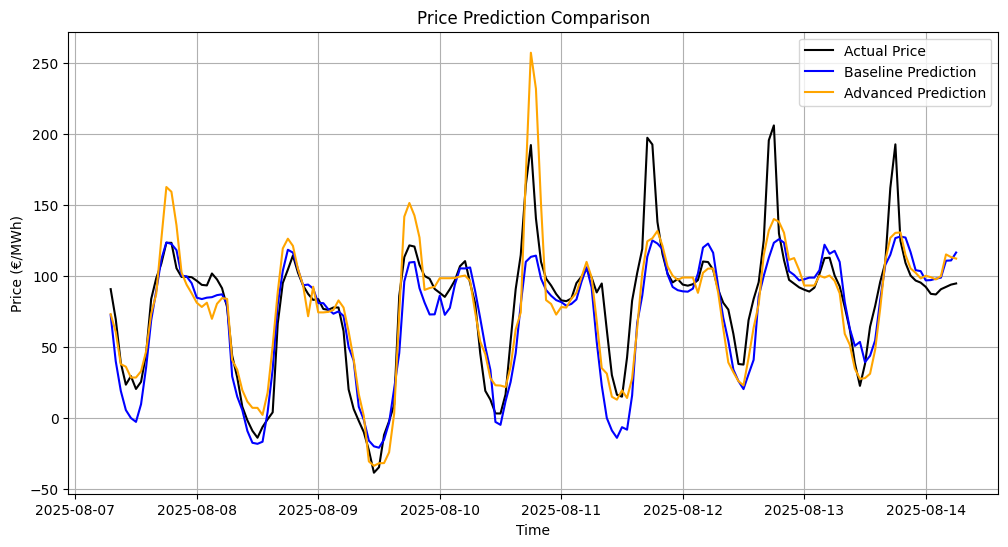

In [12]:
last_week_length = 24 * 7

fig, ax = plt.subplots(figsize=(12, 6))

time_index = y_test.index

ax.plot(time_index[:last_week_length], y_test[:last_week_length], label='Actual Price', color='black')
ax.plot(time_index[:last_week_length], y_pred_baseline[:last_week_length], label='Baseline Prediction', color='blue')
ax.plot(time_index[:last_week_length], y_pred_advanced[:last_week_length], label='Advanced Prediction', color='orange')

ax.set_xlabel('Time')
ax.set_ylabel('Price (€/MWh)')
ax.set_title('Price Prediction Comparison')
ax.legend()
ax.grid(True)

plt.show()

We'll also create scatter plots to analyze prediction accuracy:
- Each point represents one hourly prediction vs actual price
- Points closer to the diagonal line indicate better predictions
- Comparing the two plots shows whether news features improve prediction alignment with actual prices

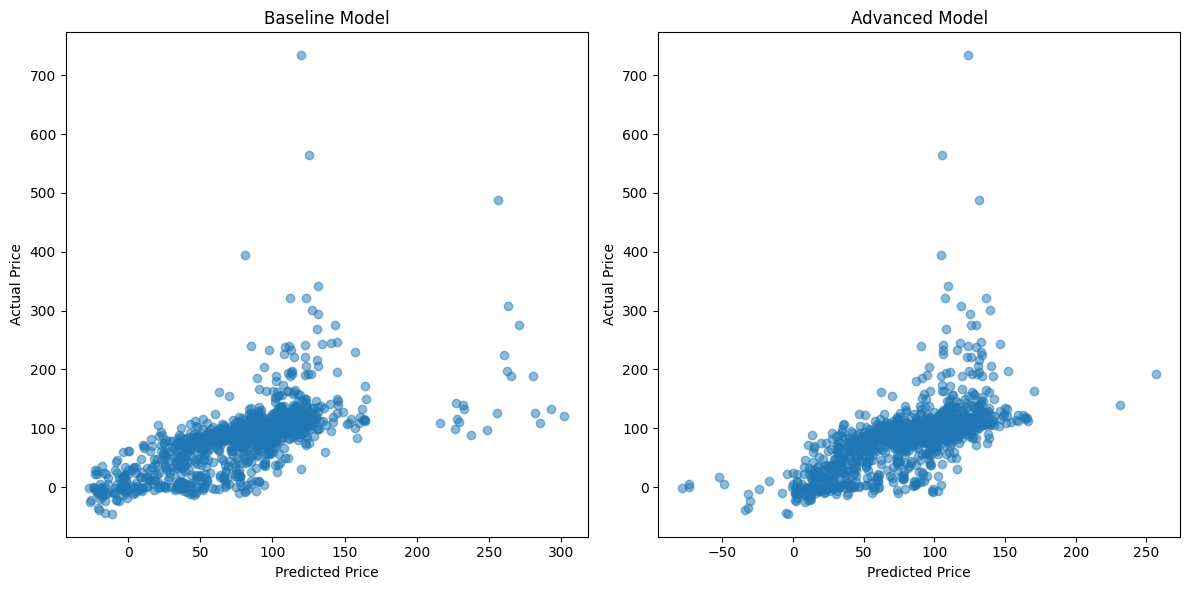

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].scatter(y_pred_baseline, y_test, alpha=0.5)
ax[0].set_xlabel('Predicted Price')
ax[0].set_ylabel('Actual Price')
ax[0].set_title('Baseline Model')

ax[1].scatter(y_pred_advanced, y_test, alpha=0.5)
ax[1].set_xlabel('Predicted Price')
ax[1].set_ylabel('Actual Price')
ax[1].set_title('Advanced Model')

plt.tight_layout()
plt.show()

---

# Backtesting a Trading Strategy (WIP!)

We simulate a practical trading strategy based on our predictions:

**Strategy Logic**:
- Each day at 12:00 UTC, we observe the day-ahead auction prices
- We predict the spot price 24 hours ahead for each hour
- **Trading Rule**: If predicted spot price > auction price → buy (go long), otherwise hold
- **Profit Calculation**: PnL = (actual_spot - auction_price) × indicator of trade

**Outcomes**:
- Positive PnL when spot price exceeds auction price (we profit from the spread)
- Zero PnL when we don't trade
- Negative PnL when we trade but spot price is below auction price (we lose from the spread)

We'll test this strategy for both the baseline and advanced models and compare their cumulative profits.

Below is a visualization showing trading opportunities (green areas = profit potential, red areas = loss risk):

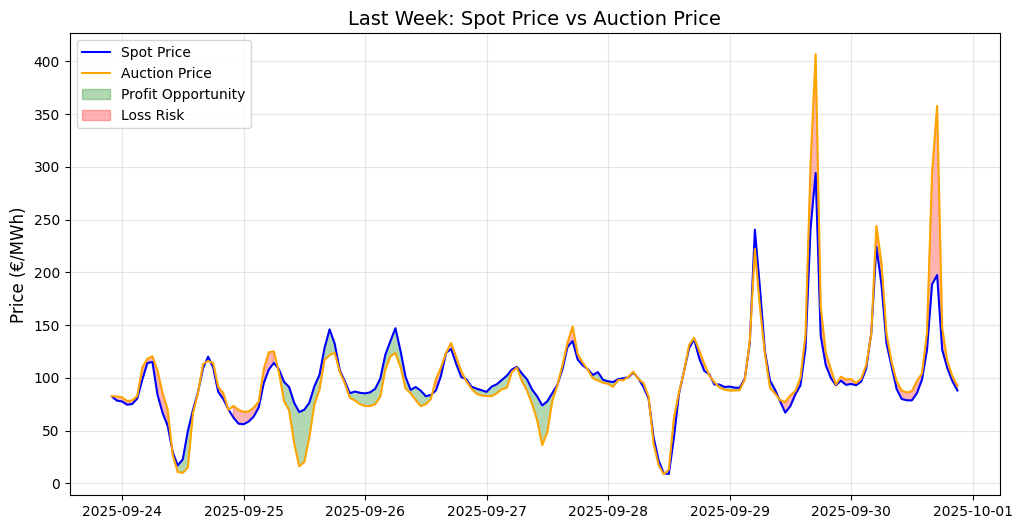

In [14]:
last_week_data = master_df.tail(24 * 7)

fig, ax = plt.subplots(figsize=(12, 6))

profit_opportunities = last_week_data['spot_price'] > last_week_data['auction_price']
profit_difference = last_week_data['spot_price'] - last_week_data['auction_price']

ax.plot(last_week_data.index, last_week_data['spot_price'], label='Spot Price', color='blue')
ax.plot(last_week_data.index, last_week_data['auction_price'], label='Auction Price', color='orange')

ax.fill_between(last_week_data.index, 
                  last_week_data['auction_price'], 
                  last_week_data['spot_price'],
                  where=profit_opportunities,
                  color='green', alpha=0.3, label='Profit Opportunity')

ax.fill_between(last_week_data.index, 
                  last_week_data['spot_price'], 
                  last_week_data['auction_price'],
                  where=~profit_opportunities,
                  color='red', alpha=0.3, label='Loss Risk')

ax.set_ylabel('Price (€/MWh)', fontsize=12)
ax.set_title('Last Week: Spot Price vs Auction Price', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)


To validate our backtest results, let's examine the last week in detail:
1. **Hourly PnL comparison**: Bar chart showing profit/loss per hour for both models
2. **Price visualization**: Spot vs auction prices to understand the underlying market dynamics
3. **Buy signals**: Show when each model decided to trade

This detailed view helps us understand the differences in trading behavior between the baseline and advanced models and verify that our backtest is working correctly.

Backtesting: 100%|██████████| 273/273 [00:03<00:00, 69.16it/s]


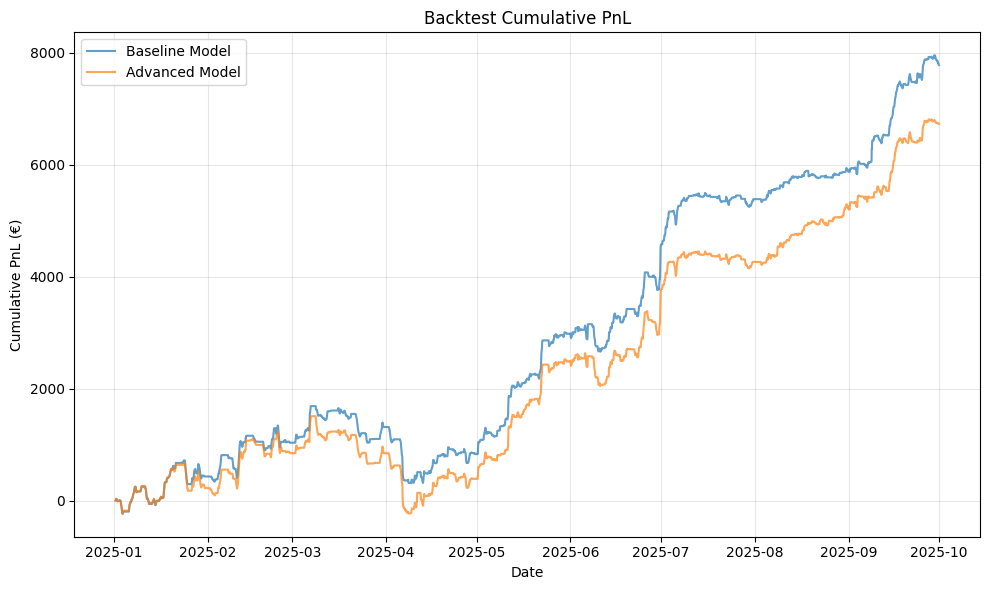

In [15]:
# Get all timestamps that are at or near 12:00h UTC (within 15 minutes)
trading_times = []
for timestamp in master_df.index:
    if timestamp.hour == 12 and timestamp.minute == 0:
        trading_times.append(timestamp)

baseline_results = []
advanced_results = []

for trade_time in tqdm(trading_times, desc="Backtesting"):
    
    next_day_mask = (master_df.index > trade_time) & (master_df.index <= trade_time + pd.Timedelta(hours=24))
    next_day_indices = master_df.index[next_day_mask]

            
    X_baseline_pred = master_df.loc[next_day_indices, baseline_features]
    X_advanced_pred = master_df.loc[next_day_indices, advanced_features]
        
    baseline_preds = baseline_model.predict(X_baseline_pred)
    advanced_preds = advanced_model.predict(X_advanced_pred)
        
    actual_spots = master_df.loc[next_day_indices, 'spot_price'].values
    auction_prices = master_df.loc[next_day_indices, 'auction_price'].values
        
    baseline_trades = baseline_preds > auction_prices
    advanced_trades = advanced_preds > auction_prices
        
    # Append one result per hour (not one result per day)
    for i, idx in enumerate(next_day_indices):
        baseline_pnl = (actual_spots[i] - auction_prices[i]) * baseline_trades[i]
        advanced_pnl = (actual_spots[i] - auction_prices[i]) * advanced_trades[i]
        
        baseline_results.append({
            'timestamp': idx,
            'pnl': baseline_pnl,
            'num_trades': baseline_trades[i]
        })
        
        advanced_results.append({
            'timestamp': idx,
            'pnl': advanced_pnl,
            'num_trades': advanced_trades[i]
        })
        

baseline_results_df = pd.DataFrame(baseline_results)
advanced_results_df = pd.DataFrame(advanced_results)

# Plot cumulative PnL
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(baseline_results_df['timestamp'], baseline_results_df['pnl'].cumsum(), 
        label='Baseline Model', alpha=0.7)
ax.plot(advanced_results_df['timestamp'], advanced_results_df['pnl'].cumsum(), 
        label='Advanced Model', alpha=0.7)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative PnL (€)')
ax.set_title('Backtest Cumulative PnL')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

To make sure the result above is correct let's plot the daily PnL for each strategy as well as the spot vs auction price

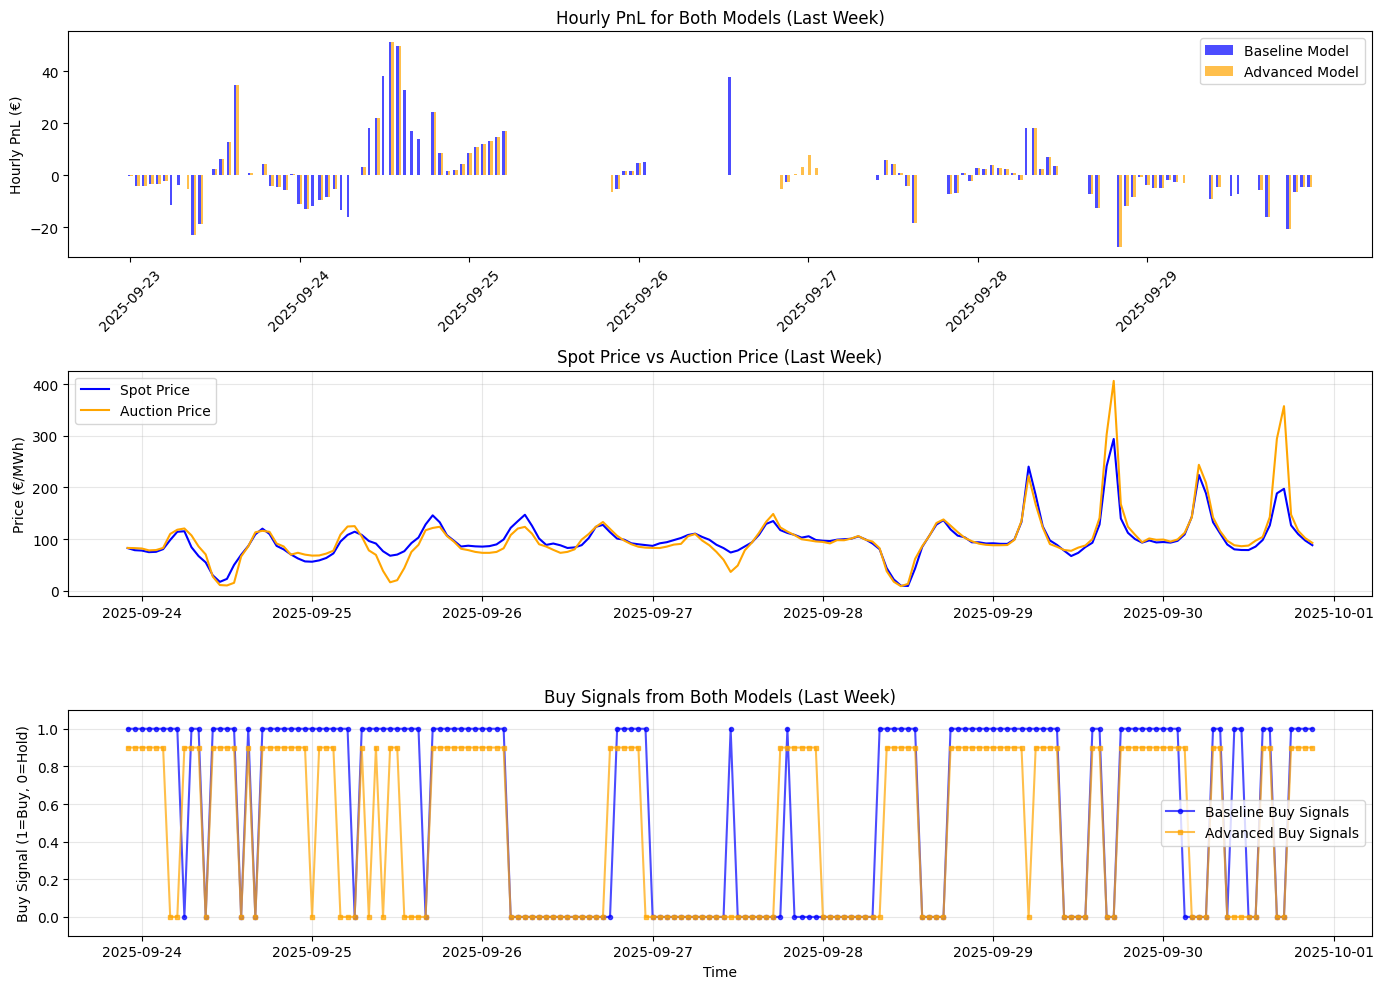

In [30]:
# Filter baseline and advanced PnL results for last week only (hourly PnL)
last_week_start = last_week_data.index.min()
last_week_end = last_week_data.index.max()

# Filter the results dataframes for hourly PnL within last week
baseline_last_week = baseline_results_df[
    (baseline_results_df['timestamp'] >= last_week_start) & 
    (baseline_results_df['timestamp'] <= last_week_end)
]
advanced_last_week = advanced_results_df[
    (advanced_results_df['timestamp'] >= last_week_start) & 
    (advanced_results_df['timestamp'] <= last_week_end)
]

# Calculate buy signals for both models on last week data
last_week_indices = last_week_data.index
X_baseline_pred = master_df.loc[last_week_indices, baseline_features]
X_advanced_pred = master_df.loc[last_week_indices, advanced_features]

baseline_preds = baseline_model.predict(X_baseline_pred)
advanced_preds = advanced_model.predict(X_advanced_pred)

baseline_buy_signals = baseline_preds > last_week_data['auction_price'].values
advanced_buy_signals = advanced_preds > last_week_data['auction_price'].values

fig, ax = plt.subplots(3, 1, figsize=(14, 10))

# Plot hourly PnL for both models (separate bars, not overlaid)
x_pos = range(len(baseline_last_week))
width = 0.35

ax[0].bar([i - width/2 for i in x_pos], baseline_last_week['pnl'], width, 
          label='Baseline Model', alpha=0.7, color='blue')
ax[0].bar([i + width/2 for i in x_pos], advanced_last_week['pnl'], width, 
          label='Advanced Model', alpha=0.7, color='orange')
ax[0].set_ylabel('Hourly PnL (€)')
ax[0].set_title('Hourly PnL for Both Models (Last Week)')
ax[0].legend()
ax[0].set_xticks(x_pos[::24])
ax[0].set_xticklabels([baseline_last_week['timestamp'].iloc[i].strftime('%Y-%m-%d') for i in x_pos[::24]], rotation=45)

# Plot spot vs auction price for last week
ax[1].plot(last_week_data.index, last_week_data['spot_price'], label='Spot Price', color='blue', linewidth=1.5)
ax[1].plot(last_week_data.index, last_week_data['auction_price'], label='Auction Price', color='orange', linewidth=1.5)
ax[1].set_ylabel('Price (€/MWh)')
ax[1].set_title('Spot Price vs Auction Price (Last Week)')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

# Plot buy signals from both models
ax[2].plot(last_week_data.index, baseline_buy_signals.astype(int), 
           label='Baseline Buy Signals', marker='o', markersize=3, alpha=0.7, color='blue')
ax[2].plot(last_week_data.index, advanced_buy_signals.astype(int) * 0.9, 
           label='Advanced Buy Signals', marker='s', markersize=3, alpha=0.7, color='orange')
ax[2].set_ylabel('Buy Signal (1=Buy, 0=Hold)')
ax[2].set_xlabel('Time')
ax[2].set_title('Buy Signals from Both Models (Last Week)')
ax[2].legend()
ax[2].set_ylim(-0.1, 1.1)
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()